# Notebook 3: Modeling

This notebook trains the Oracle survival models, validates with 5-fold CV, and generates the final submission file.

In [10]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
from src.data import load_train_data, load_test_data
from src.feature_engineering import (
    master_oracle_engineering,
    FEATURE_COLUMNS,
    scale_features,
)
from src.modeling import (
    run_econometric_baseline_sksurv,
    train_cv_rsf,
    train_final_rsf,
    generate_submission,
)

train_df = load_train_data('../data/raw/train.csv')
test_df = load_test_data('../data/raw/test.csv')

print(f"Train: {train_df.shape}, Test: {test_df.shape}")

Train: (221, 37), Test: (95, 35)


In [11]:
df_final = master_oracle_engineering(train_df)
X = df_final[FEATURE_COLUMNS].astype(float)
X_scaled, scaler = scale_features(X)

y_struct = np.array([
    (bool(e), t)
    for e, t in zip(df_final['event'], df_final['time_to_hit_hours'])
], dtype=[('event', 'bool'), ('time', 'float')])

print(f"Prepared X_scaled: {X_scaled.shape}")
print(f"Prepared y_struct: {len(y_struct)}")

Prepared X_scaled: (221, 6)
Prepared y_struct: 221



📜 Econometric Baseline: Cox Proportional Hazards (sksurv version)
{'feature': ['log_fire_gravity', 'dist_min_ci_0_5h', 'is_high_gravity_danger', 'fire_volatility', 'alignment_abs', 'gravity_momentum'], 'coef': [np.float64(-0.2481747762791557), np.float64(-103.59157860565045), np.float64(0.8359111090217674), np.float64(0.20820778956277322), np.float64(0.08632771187659556), np.float64(-7.521414232040066e-05)], 'Hazard_Ratio (exp_coef)': [np.float64(0.7802235667887808), np.float64(1.0250594173756024e-45), np.float64(2.3069149420862174), np.float64(1.2314690293766293), np.float64(1.090163529308412), np.float64(0.9999247886861923)]}


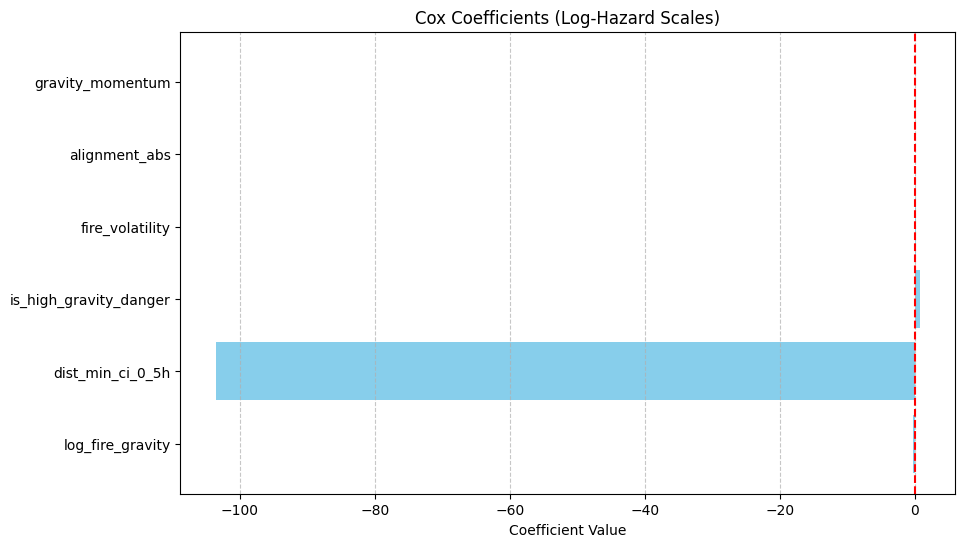

In [12]:
cph_model = run_econometric_baseline_sksurv(X_scaled, y_struct)

In [13]:
cv_results = train_cv_rsf(X_scaled, y_struct)

final_model = train_final_rsf(X_scaled, y_struct)
print(f"Final RSF model trained")

🔬 Đang huấn luyện Oracle RSF (5-Fold CV)...
Fold 1: Hybrid = 0.9641 (C-Idx: 0.9488, W-Brier: 0.0293)
Fold 2: Hybrid = 0.9668 (C-Idx: 0.9523, W-Brier: 0.0270)
Fold 3: Hybrid = 0.8326 (C-Idx: 0.9176, W-Brier: 0.2038)
Fold 4: Hybrid = 0.9647 (C-Idx: 0.9330, W-Brier: 0.0217)
Fold 5: Hybrid = 0.9675 (C-Idx: 0.9461, W-Brier: 0.0233)

✅ FINAL MASTER SCORE: 0.9391
Final RSF model trained


In [14]:
def generate_submission(test_df, model, scaler, feature_columns):
    test_processed = master_oracle_engineering(test_df)
    test_features = test_processed[feature_columns].astype(float)
    test_features_scaled = scaler.transform(test_features)
    
    # Predict survival functions
    survival_functions = model.predict_survival_function(test_features_scaled)
    
    # Time points for submission
    time_points = [12, 24, 48, 72]
    
    # Extract survival probabilities at each time point, clipped to domain
    probs = []
    for sf in survival_functions:
        max_time = sf.domain[1]
        prob_row = [sf(min(t, max_time)) for t in time_points]
        probs.append(prob_row)
    
    submission_df = pd.DataFrame(probs, columns=['prob_12h', 'prob_24h', 'prob_48h', 'prob_72h'])
    submission_df['event_id'] = test_processed['event_id']
    submission_df = submission_df[['event_id', 'prob_12h', 'prob_24h', 'prob_48h', 'prob_72h']]
    
    submission_df.to_csv('../outputs/submission.csv', index=False)
    print("Submission file generated at ../outputs/submission.csv")
    return submission_df

In [15]:
submission = generate_submission(test_df, final_model, scaler, FEATURE_COLUMNS)
print(submission.head())

d:\ai\wid\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomSurvivalForest was fitted with feature names
  warnings.warn(


Submission file generated at ../outputs/submission.csv
   event_id  prob_12h  prob_24h  prob_48h  prob_72h
0  10662602  0.983259  0.974298  0.972991  0.916905
1  13353600  0.409868  0.152203  0.071123  0.036209
2  13942327  0.983116  0.973859  0.972553  0.916467
3  16112781  0.380296  0.131456  0.066079  0.034881
4  17132808  0.913259  0.894718  0.892677  0.850298
